SS gain = 0.909 rad/s/V  |  V for setpoint = 55.0 V
Running PID...
PID SS speed (t=2-3s): 49.73 rad/s  (target=50.0)

Training Q-Learning (400 episodes)...
  Ep 100/400 | ε=0.366 | AvgR(50)=-10.579
  Ep 200/400 | ε=0.134 | AvgR(50)=-7.947
  Ep 300/400 | ε=0.050 | AvgR(50)=-6.071
  Ep 400/400 | ε=0.050 | AvgR(50)=-4.887
Testing RL (greedy)...
RL SS speed (t=2-3s): 50.00 rad/s  (target=50.0)

─────── PERFORMANCE METRICS ───────────────
Metric                         PID  Q-Learning
──────────────────────────────────────────────
Rise Time (s)                0.275       0.055
Overshoot (%)                    0        1.99
Settling Time (s)             1.47       0.075
MSE (rad/s)²                0.2247      0.0527
Recovery Time (s)             0.15        0.03

Main plot saved.
Metrics table saved.


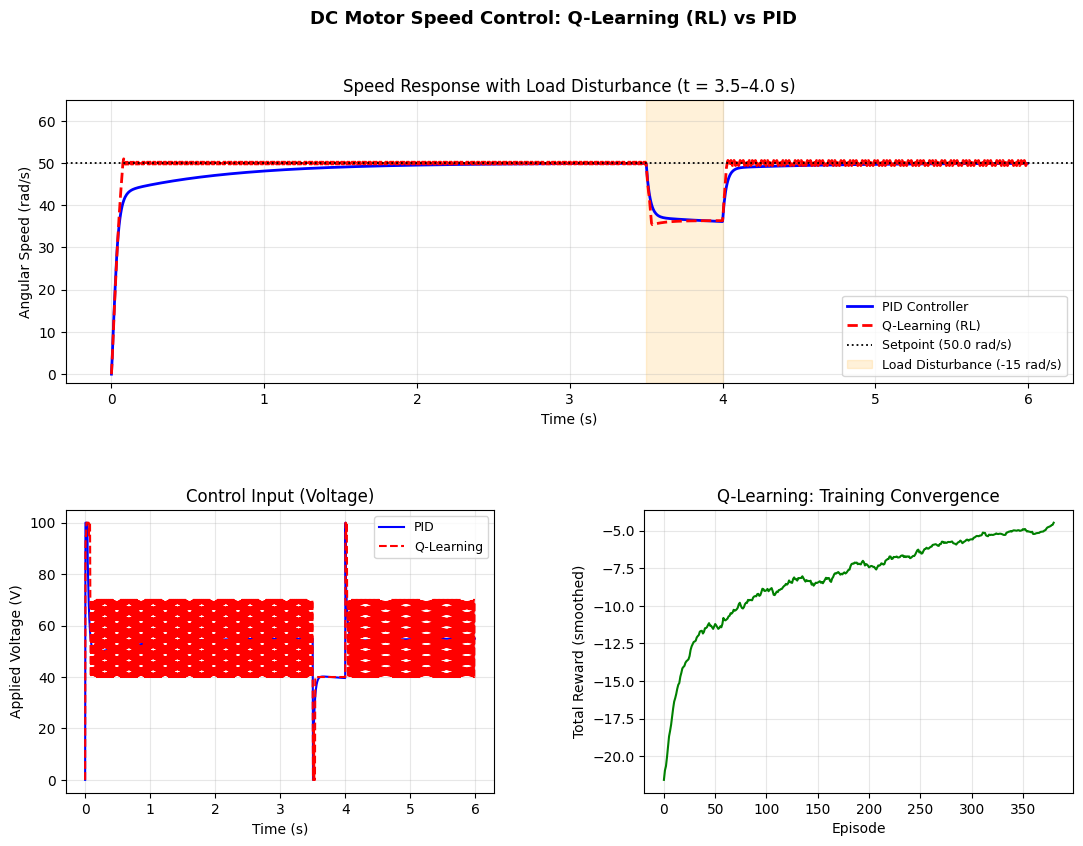

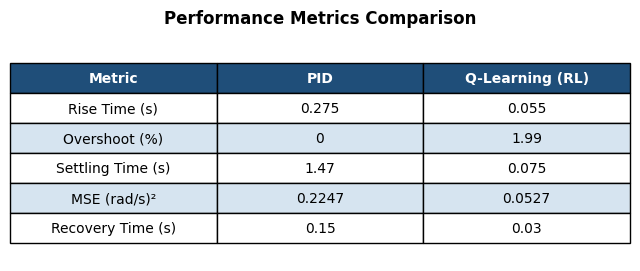

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import expm
import os

# Ensure the output directory exists
output_dir = "/mnt/user-data/outputs/"
os.makedirs(output_dir, exist_ok=True)

# ─── PLANT ────────────────────────────────
# Standard DC motor (Nise/Ogata textbook values)
# G(s) = K / (s*(tau*s + 1))  ≈ speed control simplified
# More precisely: omega(s)/V(s) = Km/[(Js+b)(Ls+R) + Km^2]
# Use parameters that give ~1 rad/s per volt at SS

J=0.01
b=0.1
Km=0.1
R=1.0
L=0.001   # Small L -> fast electrical

# SS gain = Km/(R*b + Km^2) = 0.1/(0.1 + 0.01) = 0.909 rad/s/V
dt=0.005
t_end=6.0
t=np.arange(0,t_end,dt)
N=len(t)
SETPOINT=50.0

# Need ~55V for 50 rad/s; use V_MAX=100V
V_MAX=100.0

A=np.array([[-R/L,-Km/L],[Km/J,-b/J]])
B=np.array([1/L,0.0])
C=np.array([0.0,1.0])

ss_gain = C@(-np.linalg.inv(A)@B)
print(f"SS gain = {ss_gain:.3f} rad/s/V  |  V for setpoint = {SETPOINT/ss_gain:.1f} V")

Mmat=np.zeros((3,3))
Mmat[:2,:2]=A*dt
Mmat[:2,2]=B*dt

eM=expm(Mmat); Ad=eM[:2,:2]; Bd=eM[:2,2]

def step(x,u): return Ad@x+Bd*u

# ─── PID ─────────────────────────────────
def pid_simulate():
    Kp,Ki,Kd=5.0,8.0,0.05
    x=np.zeros(2)
    spd=np.zeros(N)
    volt=np.zeros(N)
    integral=0.0; prev_err=0.0
    dist=np.zeros(N); dist[int(3.5/dt):int(4.0/dt)]=-15.0
    for i in range(1,N):
        err=SETPOINT-C@x+dist[i-1]
        integral=np.clip(integral+err*dt,-200,200)
        deriv=(err-prev_err)/dt
        u=np.clip(Kp*err+Ki*integral+Kd*deriv,0,V_MAX)
        volt[i]=u; prev_err=err
        x=step(x,u); spd[i]=C@x
    return spd,volt

print("Running PID...")
pid_spd,pid_volt=pid_simulate()
ss=np.mean(pid_spd[int(2/dt):int(3/dt)])
print(f"PID SS speed (t=2-3s): {ss:.2f} rad/s  (target={SETPOINT})")

# ─── Q-LEARNING ───────────────────────────────
# State: discretize error in [-60, 60] into 61 bins
# Action: 21 voltage levels 0..V_MAX
N_STATES=61
N_ACTIONS=21
V_LEVELS=np.linspace(0,V_MAX,N_ACTIONS)

def e2s(err):
    return int(np.clip((err+60)/120*(N_STATES-1),0,N_STATES-1))

alpha=0.4
gamma=0.95
Q=np.zeros((N_STATES,N_ACTIONS))
rewards=[]
epsilon=1.0; eps_decay=0.99; eps_min=0.05

N_EP=400
print(f"\nTraining Q-Learning ({N_EP} episodes)...")
for ep in range(N_EP):
    x=np.zeros(2)
    total_r=0.0
    for i in range(1,N):
        err=SETPOINT-C@x
        s=e2s(err)
        a=np.random.randint(N_ACTIONS) if np.random.rand()<epsilon else np.argmax(Q[s])
        u=V_LEVELS[a]
        x_new=step(x,u)
        spd_new=C@x_new
        err2=SETPOINT-spd_new
        s2=e2s(err2)
        # Reward: squared error penalty + small control effort penalty
        r=-(err2**2)/(SETPOINT**2) - 0.001*(u/V_MAX)**2
        Q[s,a]+=alpha*(r+gamma*np.max(Q[s2])-Q[s,a])
        x=x_new
        total_r+=r
    epsilon=max(eps_min,epsilon*eps_decay)
    rewards.append(total_r)
    if (ep+1)%100==0:
        print(f"  Ep {ep+1}/{N_EP} | ε={epsilon:.3f} | AvgR(50)={np.mean(rewards[-50:]):.3f}")

# Greedy test with disturbance
print("Testing RL (greedy)...")
x=np.zeros(2)
rl_spd=np.zeros(N)
rl_volt=np.zeros(N)
dist=np.zeros(N)
dist[int(3.5/dt):int(4.0/dt)]=-15.0
for i in range(1,N):
    err_d=SETPOINT-C@x+dist[i-1]
    s=e2s(err_d)
    a=np.argmax(Q[s])
    u=V_LEVELS[a]
    rl_volt[i]=u
    x=step(x,u)
    rl_spd[i]=C@x
ss_rl=np.mean(rl_spd[int(2/dt):int(3/dt)])
print(f"RL SS speed (t=2-3s): {ss_rl:.2f} rad/s  (target={SETPOINT})")

# ─── METRICS ────────────────────────────────
def metrics(spd):
    band=0.02*SETPOINT
    t10=next((i*dt for i,v in enumerate(spd) if v>=0.1*SETPOINT),None)
    t90=next((i*dt for i,v in enumerate(spd) if v>=0.9*SETPOINT),None)
    rise=round(t90-t10,3) if (t10 and t90) else 'N/A'
    peak=max(spd); OS=round(max(0,(peak-SETPOINT)/SETPOINT*100),2)
    settle='N/A'
    if t90:
        idx90=int(t90/dt)
        idx_dist=int(3.5/dt)-100
        for i in range(idx90,idx_dist):
            if all(abs(spd[j]-SETPOINT)<=band for j in range(i,min(i+100,idx_dist))):
                settle=round(i*dt,3); break
    ss_win=spd[int(1.5/dt):int(3.0/dt)]
    mse=round(float(np.mean((ss_win-SETPOINT)**2)),4)
    rec='N/A'
    for i in range(int(4.0/dt),N):
        if abs(spd[i]-SETPOINT)<=band:
            rec=round((i-int(4.0/dt))*dt,3)
            break
    return {"Rise Time (s)":rise,"Overshoot (%)":OS,"Settling Time (s)":settle,
            "MSE (rad/s)²":mse,"Recovery Time (s)":rec}

pm=metrics(pid_spd); rm=metrics(rl_spd)
print("\n─────── PERFORMANCE METRICS ───────────────")
print(f"{'Metric':<22}{'PID':>12}{'Q-Learning':>12}")
print("─"*46)
for k in pm: print(f"{k:<22}{str(pm[k]):>12}{str(rm[k]):>12}")

# ─── PLOTS ───────────────────────────────
fig=plt.figure(figsize=(13,9))
fig.suptitle("DC Motor Speed Control: Q-Learning (RL) vs PID",
             fontsize=13,fontweight='bold')
gs=gridspec.GridSpec(2,2,figure=fig,hspace=0.45,wspace=0.35)

ax1=fig.add_subplot(gs[0,:])
ax1.plot(t,pid_spd,'b-',lw=2,label='PID Controller')
ax1.plot(t,rl_spd,'r--',lw=2,label='Q-Learning (RL)')
ax1.axhline(SETPOINT,color='k',ls=':',lw=1.3,label=f'Setpoint ({SETPOINT} rad/s)')
ax1.axvspan(3.5,4.0,alpha=0.15,color='orange',label='Load Disturbance (-15 rad/s)')
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Angular Speed (rad/s)")
ax1.set_title("Speed Response with Load Disturbance (t = 3.5–4.0 s)")
ax1.legend(fontsize=9)
ax1.grid(True,alpha=0.3)
ymin=min(0,min(pid_spd.min(),rl_spd.min())-2)
ax1.set_ylim([ymin, SETPOINT*1.3])

ax2=fig.add_subplot(gs[1,0])
ax2.plot(t,pid_volt,'b-',lw=1.5,label='PID')
ax2.plot(t,rl_volt,'r--',lw=1.5,label='Q-Learning')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Applied Voltage (V)")
ax2.set_title("Control Input (Voltage)")
ax2.legend(fontsize=9)
ax2.grid(True,alpha=0.3)

w=20; sm=np.convolve(rewards,np.ones(w)/w,mode='valid')
ax3=fig.add_subplot(gs[1,1])
ax3.plot(sm,color='green',lw=1.5)
ax3.set_xlabel("Episode")
ax3.set_ylabel("Total Reward (smoothed)")
ax3.set_title("Q-Learning: Training Convergence")
ax3.grid(True,alpha=0.3)

plt.savefig(os.path.join(output_dir, "dc_motor_rl_vs_pid.png"),dpi=150,bbox_inches='tight')
print("\nMain plot saved.")

fig2,ax=plt.subplots(figsize=(8,2.8))
ax.axis('off')
rows=[[k,pm[k],rm[k]] for k in pm]
tbl=ax.table(cellText=rows,colLabels=['Metric','PID','Q-Learning (RL)'],
             cellLoc='center',loc='center',colColours=['#1F4E79']*3)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10); tbl.scale(1,1.8)
for (r,c),cell in tbl.get_celld().items():
    if r==0: cell.set_text_props(color='white',fontweight='bold')
    elif r%2==0: cell.set_facecolor('#D6E4F0')
plt.title("Performance Metrics Comparison",fontweight='bold',pad=16)
plt.savefig(os.path.join(output_dir, "metrics_table.png"),dpi=150,bbox_inches='tight')
print("Metrics table saved.")